# **Kaggle HW5: Omar Ahmad**

**Remember to write your team name above, which MUST match your team name on Kaggle!!** Assignments without a team name will receive a 0/40 on the "accuracy on test data" component of this assignment's grade.

### **Load the Data**

In [ ]:
# This cell is necessary only if you are running on Google Colab. It downloads the files to your
# Colab instance so you don't have to upload them here.

import requests

def save_file(url, file_name):
    r = requests.get(url)
    with open(file_name, 'wb') as f:
      f.write(r.content)

save_file('https://courses.cs.washington.edu/courses/cse416/23sp/homeworks/hw5/edx_train.csv',
          'edx_train.csv')
save_file('https://courses.cs.washington.edu/courses/cse416/23sp/homeworks/hw5/edx_test.csv',
          'edx_test.csv')

### **Sample Code: Random Classifier**

**NOTE**: This classifier **DOES NOT** count as one of the 2 required for this assignment! It is merely here to illstrate how to submit your predictions.

See the Kaggle assignment (Data tab) for a description of each column in the dataset. You are creating a classifier to predict whether or not a student will get certified, stored in the `"certified"` column.

In [ ]:
import pandas as pd
from sklearn.dummy import DummyClassifier

target = "certified" # target column

# This classifier returns labels sampled uniformly at random
df_train = pd.read_csv('edx_train.csv')
dummy_model = DummyClassifier(strategy="uniform")
dummy_model.fit(df_train.drop(target, axis=1), df_train[target])

DummyClassifier(strategy='uniform')

The code below generates predictions on the test set, and outputs the predictions into a CSV file.

In [ ]:
# Generate predictions on the test set
df_test = pd.read_csv('edx_test.csv')
predictions = dummy_model.predict(df_test)

# Save your predictions as a CSV
to_save = df_test[['userid_DI']].copy()
to_save.loc[:, 'certified'] = predictions
to_save.to_csv('submission.csv', index=False)

# See below for instructions on how to upload submission.csv to Kaggle,
# in order to evaluate your model and get points.

### **[5 Pts] Model Comparison**

**Instructions**: Run at least 2 different classification models. The classification models we have learned in class are: [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), [k-Nearest Neighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), [Decision Trees](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), [Random Forests](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html), and [AdaBoost](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html), [Neural Networks](https://scikit-learn.org/stable/modules/neural_networks_supervised.html). For each model, try at least 2 different hyperparameter settings.

Then, make one or more visualizations that let you compare the models you trained. Sample visualizations you can make include confusion matrices, or graphs of train and validation accuracy/error. See past section and homework code for how to make these visualizations.

In this code chunk, I prepared the dataset by separating the target variable (certified) from the input features and removing the userid_DI column since it is only an identifier and not useful for prediction. I handled missing values by filling numerical columns with their median values and categorical columns with a placeholder value. Categorical variables were then converted into numerical form using one-hot encoding so they could be used in the models.
Next, I split the data into training and validation sets to evaluate model performance on unseen data. I trained two different classification methods; Logistic Regression and Random Forest and tested two different hyperparameter settings for each model. For each configuration, I calculated both training and validation accuracy to compare performance and assess potential overfitting.
Finally, I visualized the results using a bar chart to compare training and validation accuracy across models, and I generated a confusion matrix for the best-performing model to better understand its prediction performance.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

                      model  train_acc   val_acc
3  RF depth=None, trees=600   1.000000  0.974315
2    RF depth=12, trees=300   0.963888  0.961187
1              LogReg C=0.1   0.959606  0.960616
0              LogReg C=1.0   0.967599  0.960046

Best model based on validation accuracy:
RF depth=None, trees=600 with val_acc = 0.9743


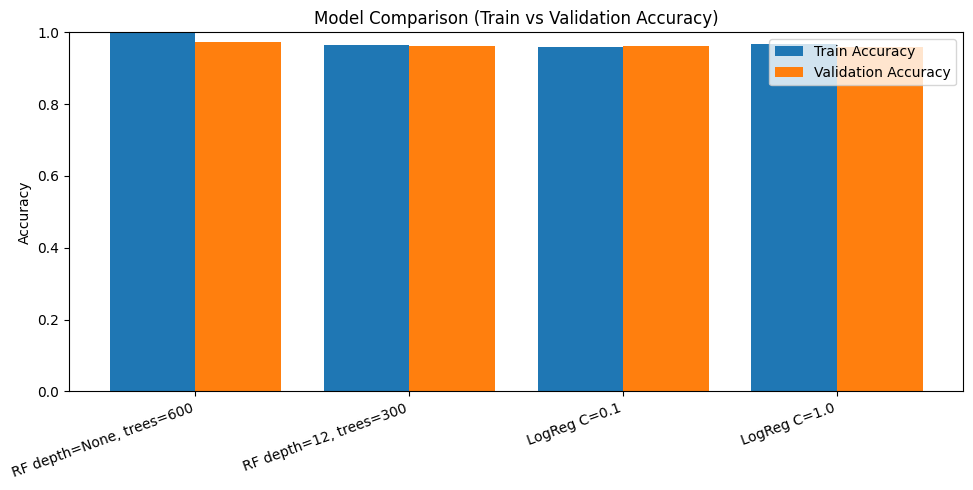

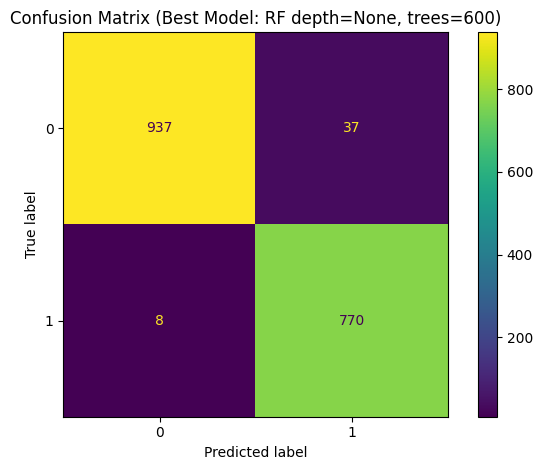

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

df_train = pd.read_csv("edx_train.csv")
df_test  = pd.read_csv("edx_test.csv")

target = "certified"
id_col = "userid_DI"

# 2) Separate X and y
# drop userid_DI because it's just an ID (not a real feature)
y = df_train[target].astype(int)
X = df_train.drop(columns=[target, id_col])

# 3) preprocessing
#   Fill missing values
#    One-hot encode categorical columns
X = X.copy()

# Fill numeric missing values with median (middle-ish value)
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

#fill categorical missing values with a string
cat_cols = X.select_dtypes(include=["object"]).columns
X[cat_cols] = X[cat_cols].fillna("unk")

# One hot encode categoricals; turn categories into 0/1 columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# 4 Train/Validation split
#  Validation simulates "unseen" data
#stratify=y keeps class balance similar in both splits
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Define models to try:
#    Logistic Regression with 2 different C values
#   Random Forest with 2 different settings
experiments = [
    ("LogReg C=1.0",  LogisticRegression(max_iter=2000, C=1.0)),
    ("LogReg C=0.1",  LogisticRegression(max_iter=2000, C=0.1)),

    ("RF depth=12, trees=300", RandomForestClassifier(max_depth=12, n_estimators=300, random_state=42, n_jobs=-1)),
    ("RF depth=None, trees=600", RandomForestClassifier(max_depth=None, n_estimators=600, random_state=42, n_jobs=-1)),
]

results = []
best_model = None
best_name = None
best_val_acc = -1

# 6) Train + evaluate each model
for name, model in experiments:
    # Train it
    model.fit(X_train, y_train)

    # Predict on train + val
    train_pred = model.predict(X_train)
    val_pred   = model.predict(X_val)

    # Compute accuracies
    train_acc = accuracy_score(y_train, train_pred)
    val_acc   = accuracy_score(y_val, val_pred)

    results.append({
        "model": name,
        "train_acc": train_acc,
        "val_acc": val_acc
    })

    # Keep track of the best validation model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model
        best_name = name

# Put results in a table so it's easy to read
df_results = pd.DataFrame(results).sort_values("val_acc", ascending=False)
print(df_results)

print("\nBest model based on validation accuracy:")
print(f"{best_name} with val_acc = {best_val_acc:.4f}")

# 7) Visualization: Train vs Validation accuracy bar chart
plt.figure(figsize=(10, 5))
x = np.arange(len(df_results))

plt.bar(x - 0.2, df_results["train_acc"], width=0.4, label="Train Accuracy")
plt.bar(x + 0.2, df_results["val_acc"],   width=0.4, label="Validation Accuracy")

plt.xticks(x, df_results["model"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Train vs Validation Accuracy)")
plt.legend()
plt.tight_layout()
plt.show()

# 8) Visualization: Confusion matrix for the best model
best_val_pred = best_model.predict(X_val)
cm = confusion_matrix(y_val, best_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.title(f"Confusion Matrix (Best Model: {best_name})")
plt.tight_layout()
plt.show()

After identifying the best performing model from the validation comparison. I retrained that model using the full labeled training dataset to maximize the amount of information available for learning. The same preprocessing steps used earlier. Handling missing values and one-hot encoding categorical variables were applied consistently to ensure the model received properly formatted inputs.
I then applied identical preprocessing to the test dataset, carefully aligning the feature columns so they matched the structure of the training data. This step ensures the model can correctly interpret the test inputs.
Finally, I generated predictions for the test dataset and saved them in the required Kaggle submission format, which includes the userid_DI column and the predicted certified values.

In [ ]:
# Recreate full training data which is the same preprocessing as before
y_full = df_train[target].astype(int)
X_full = df_train.drop(columns=[target, id_col])

# Fill missing values again
num_cols = X_full.select_dtypes(include=["int64", "float64"]).columns
X_full[num_cols] = X_full[num_cols].fillna(X_full[num_cols].median())

cat_cols = X_full.select_dtypes(include=["object"]).columns
X_full[cat_cols] = X_full[cat_cols].fillna("unk")

# One-hot encode
X_full = pd.get_dummies(X_full, columns=cat_cols, drop_first=False)

# Retrain best model on ALL training data
best_model.fit(X_full, y_full)

# now preprocess test data the same exact way

X_test = df_test.drop(columns=[id_col]).copy()

#Fill missing values
X_test[num_cols] = X_test[num_cols].fillna(X_full[num_cols].median())
X_test[cat_cols] = X_test[cat_cols].fillna("unk")

# one-hot encode test
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

# Align columns
# this ensures test has same columns as training
X_test = X_test.reindex(columns=X_full.columns, fill_value=0)

# Make th predictions
predictions = best_model.predict(X_test)

In [ ]:
to_save = df_test[[id_col]].copy()
to_save.loc[:, target] = predictions
to_save.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


**Remember to submit your submissions CSV FILE on Kaggle!** 40 pts come from your accuracy on the private test data.

Attend section on Thurs 5/11 for a demo of how to uppload submissions to Kaggle. We also have screenshots below (ingore summer and homework number in pictures)

Step 1: See the list of files on Colab

![See Colab Files](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/1_colab_see_files.jpg)

Step 2: Download `submission.csv`

![Download Colab File](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/2_colab_download_file.jpg)

Step 3: Join the Kaggle competition.

![Join the Kaggle Competition](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/3_kaggle_join_competition.jpg)

Step 4: Enusre your team name in Kaggle matches the one at the top of this notebook!

![Check Team Name](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/4_kaggle_team_name.jpg)

Step 5: Upload `submission.csv` to Kaggle

![Upload submission.csv](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/6_kaggle_upload_submission.jpg)



### **Discussion**



#### **[7 Pts] Training the Models**

**Instructions**: Discuss what models you tried, and what you did to improve your initial predictions. Discuss what hyperparameters you tried, and which hyperparameters seemed important for your final model. Finally, discuss what you are inferring from the above visualiation(s).

I experimented with two different classification methods: Logistic Regression and Random Forest. These models were chosen because they represent two different approaches to classification. Logistic Regression is a linear model, while Random Forest is a tree-based ensemble model that can capture more complex patterns in the data.
For Logistic Regression, I tested different values of the regularization parameter to see whether stronger regularization would improve performance. The model performed consistently across settings, but adjustments to the regularization strength did not lead to major improvements in validation performance.
For Random Forest, I experimented with different numbers of trees and different maximum tree depths. I compared a model with more restricted complexity to a model that allowed deeper trees and more estimators. Allowing the model to grow more complex improved validation performance, suggesting that the dataset benefits from a model capable of capturing nonlinear relationships.
From the visualization comparing training and validation accuracy, I observed that the best-performing Random Forest fit the training data very closely, which indicates some overfitting. However, it still achieved the strongest validation performance among all tested models. This suggests that even though the model learned the training data extremely well, it was still able to generalize effectively to unseen data. In contrast, Logistic Regression showed slightly lower overall performance, which indicates that a linear decision boundary may not fully capture the complexity of the dataset.
Overall, the Random Forest model with the most flexible configuration performed best and was selected as the final model for retraining on the full dataset before generating predictions for Kaggle.

#### **[3 Pts] Feature Selection**

**Instructions**: Discuss what features you used and whether you did some transformations on them. What features seemed important for your final model?

I used all available predictor variables in the dataset except for userid_DI, since it is simply a unique identifier and does not contain meaningful information for predicting course completion. The target variable certified was separated from the features and used as the label for training.
In terms of transformations, I handled missing values by filling numerical columns with their median values and replacing missing categorical values with a placeholder category. Because machine learning models require numerical input, I converted categorical variables into numerical form using one-hot encoding. This transformation allowed the models to interpret categories such as country, education level, and gender as binary indicator variables. No additional feature engineering was performed beyond these preprocessing steps.
For the final Random Forest model, features related to student engagement and activity appeared to be especially important. Variables that reflected how much a student interacted with the course content likely contributed strongly to predicting whether they completed the course. Demographic variables were included in the model, but engagement-based features likely had a greater impact on predictive performance, since course completion is more directly related to participation and activity than to background characteristics.
Overall, minimal feature engineering was required because Random Forest models are capable of handling nonlinear relationships and interactions between variables without needing manual feature construction.

#### **[5 Pts] Ethical Implications**

**Instructions**: Consider and discuss the ethical implications of using the model you trained. Imagine you were hired to work as a data scientist for an online education platform (exciting, right?). They want to use your model to predict which students they should tailor their course material towards so they can maximize their profits. Their idea is to use the model to help predict which student groups (i.e. from specific countries or certain educational backgrounds) would make them the most money by getting the most participants to complete their paid certificate program. Are there any ethical considerations we should think about before acting on that plan?

Although the model performs well at predicting course completion, there are important ethical considerations in how it could be used. If an online education platform were to use this model to identify which student groups are most likely to complete a paid certification program in order to maximize profit, this could raise concerns about fairness and equity.
One concern is that the model may reflect existing inequalities in access to education, technology, or resources. For example, students from certain countries or educational backgrounds may historically complete courses at higher rates due to better internet access, prior preparation, or financial stability. If the company were to focus marketing or course improvements only on those groups, it could reinforce existing disparities and limit opportunities for students from underrepresented or disadvantaged backgrounds.
Another issue is potential bias in the training data. Because the dataset is observational, it captures patterns that already exist in the system. The model does not explain why certain students complete courses at higher rates; it only identifies correlations. Using those correlations to guide profit-driven decisions could unintentionally discriminate against certain demographic groups, even if the model itself is statistically accurate.
There is also a broader ethical question about the purpose of education platforms. If decisions are driven solely by maximizing certificate revenue, the platform may prioritize students who are already likely to succeed rather than investing in support systems that help struggling students improve. A more ethical approach would be to use the model to identify students at risk of not completing a course and provide additional support or resources to improve their outcomes.
In summary, while predictive models can provide useful insights, they should be used carefully. Companies must consider fairness, bias, and equal access to opportunity before making decisions that could systematically disadvantage certain groups of learners.